In [1]:
import json
import networkx as nx
import os
import pandas as pd

import numpy as np
from typing import List

from operator import itemgetter

from pyvis.network import Network
import gravis as gv

Utilities

In [2]:
def load_scenario(path): # Note also that a graph with the components and their dependencies is returned
    graph = nx.from_pandas_adjacency(
        pd.read_csv(os.path.join(path, "graph.csv"), index_col=0),
        create_using=nx.DiGraph,
    )

    normal_metrics = pd.read_csv(
        os.path.join(path, "noissue", "metrics.csv"), header=[0, 1, 2], index_col=0
    )

    issues = {"train": [], "test": []}
    for split in issues:
        for issue in os.listdir(os.path.join(path, split)):
            if issue.startswith("."):  # Skip hidden files and folders.
                continue
            metrics = pd.read_csv(
                os.path.join(path, split, issue, "metrics.csv"),
                header=[0, 1, 2],
                index_col=0,
            )
            with open(os.path.join(path, split, issue, "target.json"), "r") as f:
                target = json.load(f)
            issues[split].append((metrics, target))
    return graph, normal_metrics, issues

def get_dataframe_by_quality(df, quality, prefix=False, separator='#', singleton=False):
    all_components = set([x[0] for x in df.columns])
    col_selector = [(x, quality, 'Average') for x in all_components]
    data = df[col_selector].values
    result_df = pd.DataFrame(data=data, index=df.index, columns=list(all_components))
    if singleton:
        if quality == 'latency':
            result_df = result_df.max().to_frame().T
        if quality == 'availability':
            result_df = result_df.min().to_frame().T
    if prefix:
        result_df.columns = [f"{quality}{separator}{x}" for x in result_df.columns]
    return result_df

def get_dataframe_issues_by_quality(issues_dict, quality, prefix=False, separator='#', singleton=False, target=None):

    all_dfs = []
    for idx, issue in enumerate(issues_dict['train']):
        target_metric = issue[1]
        # print(target_metric)
        if (target is None) or (target_metric['target']['metric'] == target):
            metrics_df = issue[0]
            df = get_dataframe_by_quality(metrics_df, quality, prefix=prefix, separator=separator, singleton=singleton)
            df['issue'] = idx+1 #'issue'+str(idx)
            all_dfs.append(df)
    n = len(issues_dict['train'])
    for idx, issue in enumerate(issues_dict['test']):
        target_metric = issue[1]
        # print(target_metric)
        if (target is None) or (target_metric['target']['metric'] == target):
            metrics_df = issue[0]
            df = get_dataframe_by_quality(metrics_df, quality, prefix=prefix, separator=separator, singleton=singleton)
            df['issue'] = n+idx+1 #'issue'+str(n+idx)
            all_dfs.append(df)

    return pd.concat(all_dfs)

def combine_dataframes(df, qualities=None, sampling=None, columns=None):
    separator = '#'
    q0 = get_dataframe_by_quality(df, qualities[0], prefix=True, separator=separator).copy()
    q1 = get_dataframe_by_quality(df, qualities[1], prefix=True, separator=separator).copy()
    if columns is not None:
        for c in columns:
            s = (qualities[0]+separator+c)
            if s not in q0.columns:
                q0[c] = np.nan
            s = (qualities[1]+separator+c)
            if s not in q1.columns:
                q1[c] = np.nan
        q0 = q0[[(qualities[0]+separator+c) for c in columns]]
        q1 = q1[[(qualities[1]+separator+c) for c in columns]]
    if sampling is not None:
        q0 = q0.sample(frac=sampling, random_state=1)
        q1 = q1.sample(frac=sampling, random_state=1)
    
    # modes_dict = {}
    # for c in q0.columns:
    #     modes_dict[c] = q0[c].mode()
    # for c in q1.columns:
    #     modes_dict[c] = q1[c].mode()

    return pd.concat([q0, q1], axis=1) #, modes_dict

# def combine_issues_dataframes_quality(issues_dict, quality, sampling=None, columns=None, singleton=False):
#     separator = '#'
#     q0 = get_dataframe_issues_by_quality(issues_dict, quality, prefix=True, separator=separator, singleton=singleton).copy()
#     if columns is not None:
#         for c in columns:
#             s = (quality+separator+c)
#             if s not in q0.columns:
#                 q0[c] = np.nan
#         q0 = q0[[(quality+separator+c) for c in columns]+['issue']]
#     if sampling is not None:
#         q0 = q0.sample(frac=sampling, random_state=1)
#     return q0

def combine_issues_dataframes(issues_dict, qualities=None, sampling=None, columns=None, singleton=False, target=None):
    separator = '#'
    q0 = get_dataframe_issues_by_quality(issues_dict, qualities[0], prefix=True, separator=separator, singleton=singleton, target=target).copy()
    q1 = get_dataframe_issues_by_quality(issues_dict, qualities[1], prefix=True, separator=separator, singleton=singleton, target=target).copy()
    if columns is not None:
        for c in columns:
            s = (qualities[0]+separator+c)
            if s not in q0.columns:
                q0[c] = np.nan
            s = (qualities[1]+separator+c)
            if s not in q1.columns:
                q1[c] = np.nan
        q0 = q0[[(qualities[0]+separator+c) for c in columns]+['issue']]
        q1 = q1[[(qualities[1]+separator+c) for c in columns]]
    if sampling is not None:
        q0 = q0.sample(frac=sampling, random_state=1)
        q1 = q1.sample(frac=sampling, random_state=1)
    return pd.concat([q0, q1], axis=1)

def get_root_causes(issues_dict, include_qualities=False):
    train_root_causes = [issue[1]['root_cause']['node'] for issue in issues_dict['train']]
    test_root_causes = [issue[1]['root_cause']['node'] for issue in issues_dict['test']]
    if not include_qualities:
        all_root_causes = set(train_root_causes + test_root_causes)
        return sorted(list(all_root_causes))
    
    train_qualities = [issue[1]['target']['metric'] for issue in issues_dict['train']]
    test_qualities = [issue[1]['target']['metric'] for issue in issues_dict['test']]
    all_qualities = set(zip(train_root_causes + test_root_causes, train_qualities + test_qualities))
    return list(sorted(all_qualities,key=itemgetter(0)))

In [3]:
DIR = './dataset'

CONDITIONS = [ # Scenario
        "low_traffic",
        "high_traffic",
        "temporal_traffic1",
        "temporal_traffic2",
    ]

QUALITIES = ['latency', 'availability']

### Loading no-issue dataset and flattening it

In [4]:
condition = CONDITIONS[0] # low traffic
print(condition, DIR)
graph_low, normal_metrics_low_df, low_issues_dict = load_scenario(os.path.join(DIR, condition))
print("Nodes:", graph_low.number_of_nodes())
print("Edges:", graph_low.number_of_edges())
print(normal_metrics_low_df.shape)
# normal_metrics_low_df.head()

condition = CONDITIONS[1] # high traffic
print(condition, DIR)
graph_high, normal_metrics_high_df, high_issues_dict = load_scenario(os.path.join(DIR, condition))
print("Nodes:", graph_high.number_of_nodes())
print("Edges:", graph_high.number_of_edges())
print(normal_metrics_high_df.shape)
# normal_metrics_high_df.head()

condition = CONDITIONS[2] # temporal_traffic1
print(condition, DIR)
graph_temporal1, normal_metrics_temporal1_df, temporal1_issues_dict = load_scenario(os.path.join(DIR, condition))
print("Nodes:", graph_temporal1.number_of_nodes())
print("Edges:", graph_temporal1.number_of_edges())
print(normal_metrics_temporal1_df.shape)
# normal_metrics_temporal1_df.head()

condition = CONDITIONS[3]
print(condition, DIR)
graph_temporal2, normal_metrics_temporal2_df, temporal2_issues_dict = load_scenario(os.path.join(DIR, condition))
print("Nodes:", graph_temporal2.number_of_nodes())
print("Edges:", graph_temporal2.number_of_edges())
print(normal_metrics_temporal2_df.shape)
# normal_metrics_temporal2_df.head()


low_traffic ./dataset
Nodes: 42
Edges: 44
(589, 287)
high_traffic ./dataset
Nodes: 44
Edges: 47
(589, 273)
temporal_traffic1 ./dataset
Nodes: 41
Edges: 43
(1652, 287)
temporal_traffic2 ./dataset
Nodes: 41
Edges: 43
(1652, 287)


In [5]:
# quality = QUALITIES[0] # latency
# df1 = get_dataframe_by_quality(normal_metrics_low_df, quality=quality, prefix=True)
# print(df1.shape)
# df1.sample(frac=0.1, random_state=1)

In [6]:
# quality = QUALITIES[1] # availability
# df2 = get_dataframe_by_quality(normal_metrics_low_df, quality=quality, prefix=True)
# print(df2.shape)
# df2.sample(frac=0.1, random_state=1)
# df[~df.isnull().any(axis=1)] # Select rows with no NaN values

In [7]:
ALL_COMPONENTS = list(set([c for (c,_,_) in normal_metrics_high_df.columns]))
print(len(ALL_COMPONENTS))
# ALL_COMPONENTS # These are all the microservices

39


In [8]:
sampling = 0.1 # To reduce the impact of no-issue cases

normal_metrics_low_flat_df = combine_dataframes(normal_metrics_low_df, qualities=QUALITIES, sampling=sampling, columns=ALL_COMPONENTS)
normal_metrics_low_flat_df['traffic'] = 'low_traffic'
normal_metrics_low_flat_df['issue'] = 0 #'noissue'
print(normal_metrics_low_flat_df.shape)

normal_metrics_high_flat_df = combine_dataframes(normal_metrics_high_df, qualities=QUALITIES, sampling=sampling, columns=ALL_COMPONENTS)
normal_metrics_high_flat_df['traffic'] = 'high_traffic'
normal_metrics_high_flat_df['issue'] = 0 #'noissue'
print(normal_metrics_high_flat_df.shape)

normal_metrics_temporal1_flat_df = combine_dataframes(normal_metrics_temporal1_df, qualities=QUALITIES, sampling=sampling, columns=ALL_COMPONENTS)
normal_metrics_temporal1_flat_df['traffic'] = 'temporal1'
normal_metrics_temporal1_flat_df['issue'] = 0 #'noissue'
print(normal_metrics_temporal1_flat_df.shape)

normal_metrics_temporal2_flat_df = combine_dataframes(normal_metrics_temporal2_df, qualities=QUALITIES, sampling=sampling, columns=ALL_COMPONENTS)
normal_metrics_temporal2_flat_df['traffic'] = 'temporal2'
normal_metrics_temporal2_flat_df['issue'] = 0 #'noissue'
print(normal_metrics_temporal2_flat_df.shape)

(59, 80)
(59, 80)
(165, 80)
(165, 80)


In [9]:
noissues_df = pd.concat([normal_metrics_low_flat_df, normal_metrics_high_flat_df, 
           normal_metrics_temporal1_flat_df, normal_metrics_temporal2_flat_df], ignore_index=True)
print(len(set(noissues_df.columns)))
noissues_df

80


,latency#lambda_step_readDDB,latency#SimpleSystemsManagement_AWS::SimpleSystemsManagement,latency#servi-searc.us-west-2.elb.amazonaws.com_remote,latency#AWSSimpleSystemsManagement_AWS::AWSSimpleSystemsManagement,latency#PetSearch_AWS::ECS::Fargate,latency#amazon.com_remote,latency#lambdastatusupdater_AWS::Lambda::Function,latency#lambdastatusupdater_AWS::Lambda,latency#servi-lista.us-west-2.elb.amazonaws.com_remote,latency#StepFunctions_AWS::StepFunctions,...,availability#Evidently_AWS::Evidently,availability#DynamoDB_AWS::DynamoDB,availability#petlistadoptions_client,availability#lambda_step_priceGreaterThan55,availability#www.amazon.com_remote,availability#adoptions@services-database.us-west-2.rds.amazonaws.com_Database::SQL,availability#PetSite,availability#payforadoption_AWS::ECS::Container,traffic,issue
0,0.339769,0.016328,0.012287,0.024795,0.007527,0.067254,0.076344,0.050064,0.042400,NaN,...,100.0,100.0,100.0,NaN,100.0,100.000000,100.000000,100.0,low_traffic,0
1,0.285758,0.016975,0.011218,0.022926,0.006632,0.062161,0.072444,0.048673,0.038610,NaN,...,100.0,100.0,100.0,NaN,100.0,100.000000,99.802761,100.0,low_traffic,0
2,0.333259,0.016167,0.015039,0.022742,0.005942,0.066010,0.089769,0.060777,0.041166,NaN,...,100.0,100.0,100.0,NaN,100.0,100.000000,100.000000,100.0,low_traffic,0
3,0.249950,0.015604,0.012425,0.021563,0.005723,0.064455,0.076608,0.052667,0.039923,NaN,...,100.0,100.0,100.0,NaN,100.0,100.000000,100.000000,100.0,low_traffic,0
4,0.285212,0.015967,0.012960,0.026465,0.006293,0.064842,0.062932,0.046271,0.045112,NaN,...,NaN,100.0,100.0,NaN,100.0,98.571429,100.000000,100.0,low_traffic,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
443,0.296077,0.016866,0.024890,0.021632,0.005946,0.069534,0.075504,0.053256,0.041997,NaN,...,NaN,100.0,100.0,NaN,100.0,100.000000,100.000000,100.0,temporal2,0
444,0.241840,0.015170,0.012610,0.019953,0.005946,0.066083,0.063872,0.046354,0.041646,NaN,...,100.0,100.0,100.0,100.0,100.0,100.000000,99.795082,100.0,temporal2,0
445,0.249654,0.016687,0.021821,0.023190,0.006355,0.065487,0.061438,0.046920,0.038858,NaN,...,100.0,100.0,100.0,NaN,100.0,100.000000,100.000000,100.0,temporal2,0
446,0.340221,0.015227,0.022195,0.023320,0.006530,0.070136,0.068986,0.046246,0.041301,NaN,...,NaN,100.0,100.0,NaN,100.0,100.000000,100.000000,100.0,temporal2,0


In [10]:
noissues_df.isnull().sum() # Some components have no data (either for performance or for availability)

latency#lambda_step_readDDB                                                           0
latency#SimpleSystemsManagement_AWS::SimpleSystemsManagement                          0
latency#servi-searc.us-west-2.elb.amazonaws.com_remote                                0
latency#AWSSimpleSystemsManagement_AWS::AWSSimpleSystemsManagement                    0
latency#PetSearch_AWS::ECS::Fargate                                                   0
                                                                                     ..
availability#adoptions@services-database.us-west-2.rds.amazonaws.com_Database::SQL    0
availability#PetSite                                                                  0
availability#payforadoption_AWS::ECS::Container                                       0
traffic                                                                               0
issue                                                                                 0
Length: 80, dtype: int64

In [11]:
modes_dict = {}
for c in noissues_df.columns:
    m = noissues_df[c].mode()
    if len(m) > 0:
        modes_dict[c] = m.values[0]
    else:
        print("Warning: some columns have no mode", c)
        modes_dict[c] = None
modes_dict

{'latency#lambda_step_readDDB': 0.1681612187847727,
 'latency#SimpleSystemsManagement_AWS::SimpleSystemsManagement': 0.014410424229745,
 'latency#servi-searc.us-west-2.elb.amazonaws.com_remote': 0.0100581223747812,
 'latency#AWSSimpleSystemsManagement_AWS::AWSSimpleSystemsManagement': 0.019584797320625,
 'latency#PetSearch_AWS::ECS::Fargate': 0.0049206751202619,
 'latency#amazon.com_remote': 0.0619923803421111,
 'latency#lambdastatusupdater_AWS::Lambda::Function': 0.0544895071157692,
 'latency#lambdastatusupdater_AWS::Lambda': 0.0385103455821586,
 'latency#servi-lista.us-west-2.elb.amazonaws.com_remote': 0.0359020819378688,
 'latency#StepFunctions_AWS::StepFunctions': None,
 'latency#SimpleNotificationService_AWS::SimpleNotificationService': 0.0156045116320163,
 'latency#STS_AWS::STS': 0.75452506535,
 'latency#petInfo_AWS::DynamoDB::Table': 0.0106129365518764,
 'latency#lambda_step_readDDB_AWS::Lambda::Function': 0.2643344227414634,
 'latency#https://sqs.us-west-2.amazonaws.com/Service

In [12]:
list(graph_high.nodes())

['169.254.170.2_remote',
 'AWSSimpleSystemsManagement_AWS::AWSSimpleSystemsManagement',
 'DynamoDB_AWS::DynamoDB',
 'Evidently_AWS::Evidently',
 'PGSQL Query_remote',
 'PetAdoptionStatusUpdater/prod_AWS::ApiGateway::Stage',
 'PetSearch_AWS::ECS::Fargate',
 'PetSearch_client',
 'PetSite',
 'SSM_AWS::SSM',
 'STS_AWS::STS',
 'SimpleNotificationService_AWS::SimpleNotificationService',
 'SimpleSystemsManagement_AWS::SimpleSystemsManagement',
 'StepFnStateMachine76D362E8-T67Tg48ke8oK_client',
 'amazon.com_remote',
 'lambda_step_priceGreaterThan55',
 'lambda_step_priceGreaterThan55_AWS::Lambda',
 'lambda_step_priceGreaterThan55_AWS::Lambda::Function',
 'lambda_step_priceLessThan55',
 'lambda_step_priceLessThan55_AWS::Lambda',
 'lambda_step_priceLessThan55_AWS::Lambda::Function',
 'lambda_step_readDDB',
 'lambda_step_readDDB_AWS::Lambda',
 'lambda_step_readDDB_AWS::Lambda::Function',
 'lambdastatusupdater_AWS::Lambda',
 'lambdastatusupdater_AWS::Lambda::Function',
 'payforadoption_AWS::ECS::Co

In [13]:
# Additional elements/services for graph_high
print(set(graph_high.nodes()) - set(graph_low.nodes()))
print(set(graph_low.nodes()) - set(graph_high.nodes()))

{'payforadoption_client', 'servi-payfo.us-west-2.elb.amazonaws.com_remote'}
set()


In [14]:
print(set(graph_high.nodes()) - set(graph_temporal1.nodes()))
print(set(graph_temporal1.nodes()) - set(graph_high.nodes()))

{'StepFnStateMachine76D362E8-T67Tg48ke8oK_client', 'payforadoption_client', 'servi-payfo.us-west-2.elb.amazonaws.com_remote'}
set()


In [15]:
print(set(graph_low.nodes()) - set(graph_temporal1.nodes()))
print(set(graph_temporal1.nodes()) - set(graph_low.nodes()))

{'StepFnStateMachine76D362E8-T67Tg48ke8oK_client'}
set()


In [16]:
print(set(graph_high.nodes()) - set(graph_temporal2.nodes()))
print(set(graph_temporal2.nodes()) - set(graph_high.nodes()))

{'StepFnStateMachine76D362E8-T67Tg48ke8oK_client', 'payforadoption_client', 'servi-payfo.us-west-2.elb.amazonaws.com_remote'}
set()


In [17]:
print(set(graph_low.nodes()) - set(graph_temporal2.nodes()))
print(set(graph_temporal2.nodes()) - set(graph_low.nodes()))

{'StepFnStateMachine76D362E8-T67Tg48ke8oK_client'}
set()


In [18]:
print(set(graph_temporal1.nodes()) - set(graph_temporal2.nodes()))
print(set(graph_temporal2.nodes()) - set(graph_temporal1.nodes()))

set()
set()


### Loading issue dataset and flattening it

In [19]:
# get_dataframe_issues_by_quality(low_issues_dict, quality=QUALITIES[0], prefix=True)

In [20]:
# get_dataframe_issues_by_quality(low_issues_dict, quality=QUALITIES[1], prefix=True)

In [21]:
low_issues_dict['test'][3][1]

{'target': {'node': 'PetSite',
  'metric': 'availability',
  'agg': 'Average',
  'timestamp': 1681844986},
 'root_cause': {'node': 'payforadoption_AWS::ECS::Container', 'metric': None},
 'metadata': {'reproducibility': {'command': "aws ssm put-parameter --name '/petstore/errormode1' --value 'true' --overwrite"}}}

In [22]:
sampling = None # 0.5 #0.5 # None
singleton = True # True (it means that only 1 instance per issue is selected)
target = None # QUALITIES[1] # None # QUALITIES[1]
print("Filtering QUALITY:", target)
print("Sampling=", sampling, "Singleton=", singleton)

# OUTPUT_FILENAME = 'aws_dataset_null70_sampling10_singleton_availability.csv'

issue_metrics_low_flat_df = combine_issues_dataframes(low_issues_dict, qualities=QUALITIES, singleton=singleton, 
                                                      sampling=sampling, columns=ALL_COMPONENTS, target=target)
issue_metrics_low_flat_df['traffic'] = 'low_traffic'
print(issue_metrics_low_flat_df.shape)

issue_metrics_high_flat_df = combine_issues_dataframes(high_issues_dict, qualities=QUALITIES, singleton=singleton, 
                                                       sampling=sampling, columns=ALL_COMPONENTS, target=target)
issue_metrics_high_flat_df['traffic'] = 'high_traffic'
print(issue_metrics_high_flat_df.shape)

issue_metrics_temporal1_flat_df = combine_issues_dataframes(temporal1_issues_dict, qualities=QUALITIES, singleton=singleton,
                                                            sampling=sampling, columns=ALL_COMPONENTS, target=target)
issue_metrics_temporal1_flat_df['traffic'] = 'temporal1'
print(issue_metrics_temporal1_flat_df.shape)

issue_metrics_temporal2_flat_df = combine_issues_dataframes(temporal2_issues_dict, qualities=QUALITIES, singleton=singleton,
                                                            sampling=sampling, columns=ALL_COMPONENTS, target=target)
issue_metrics_temporal2_flat_df['traffic'] = 'temporal2'
print(issue_metrics_temporal2_flat_df.shape)


Filtering QUALITY: None
Sampling= None Singleton= True


(26, 80)
(26, 80)
(8, 80)
(8, 80)


In [23]:
#issue_metrics_temporal2_flat_df

In [24]:
#issue_metrics_temporal2_flat_df['issue']

In [25]:
issues_df = pd.concat([issue_metrics_low_flat_df, issue_metrics_high_flat_df, 
           issue_metrics_temporal1_flat_df, issue_metrics_temporal2_flat_df], ignore_index=True)
issues_df

,latency#lambda_step_readDDB,latency#SimpleSystemsManagement_AWS::SimpleSystemsManagement,latency#servi-searc.us-west-2.elb.amazonaws.com_remote,latency#AWSSimpleSystemsManagement_AWS::AWSSimpleSystemsManagement,latency#PetSearch_AWS::ECS::Fargate,latency#amazon.com_remote,latency#lambdastatusupdater_AWS::Lambda::Function,latency#lambdastatusupdater_AWS::Lambda,latency#servi-lista.us-west-2.elb.amazonaws.com_remote,latency#StepFunctions_AWS::StepFunctions,...,availability#PGSQL Query_remote,availability#Evidently_AWS::Evidently,availability#DynamoDB_AWS::DynamoDB,availability#petlistadoptions_client,availability#lambda_step_priceGreaterThan55,availability#www.amazon.com_remote,availability#adoptions@services-database.us-west-2.rds.amazonaws.com_Database::SQL,availability#PetSite,availability#payforadoption_AWS::ECS::Container,traffic
0,0.367895,0.015331,0.188407,0.021756,0.038590,0.069978,0.065288,0.046232,0.038708,NaN,...,100.0,100.0,100.0,100.0,NaN,100.000000,100.0,99.781182,100.000000,low_traffic
1,0.440640,0.016726,0.027118,0.023069,0.010802,0.072610,0.081148,0.057885,0.040166,NaN,...,100.0,100.0,100.0,100.0,100.0,100.000000,100.0,96.934866,100.000000,low_traffic
2,0.464579,0.019320,0.036936,0.022320,0.012719,0.068158,0.075386,0.051316,0.066404,NaN,...,100.0,100.0,100.0,100.0,NaN,100.000000,100.0,96.288660,100.000000,low_traffic
3,0.347435,0.019133,0.038529,0.023066,0.020243,0.070237,0.075532,0.051885,0.044818,NaN,...,100.0,100.0,100.0,100.0,100.0,100.000000,100.0,99.585062,100.000000,low_traffic
4,0.320104,0.020419,0.038270,0.023975,0.013320,0.068943,0.080526,0.055021,0.042408,NaN,...,100.0,100.0,100.0,100.0,100.0,100.000000,100.0,93.209877,100.000000,low_traffic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63,0.599285,0.015836,0.019459,0.023757,0.006625,0.069646,0.075636,0.053938,0.045518,NaN,...,100.0,100.0,100.0,100.0,NaN,100.000000,100.0,98.076923,91.304348,temporal2
64,0.291246,0.017083,0.014142,0.024605,0.005877,0.066586,0.077046,0.054027,0.037556,NaN,...,100.0,100.0,100.0,100.0,NaN,100.000000,100.0,97.588832,100.000000,temporal2
65,0.340949,0.020624,0.013734,0.024352,0.007053,0.074089,0.118541,0.099645,0.042744,NaN,...,100.0,NaN,100.0,100.0,NaN,85.714286,100.0,95.823096,80.000000,temporal2
66,0.243848,0.016802,0.016893,0.024797,0.006615,0.065956,1.099596,1.076891,0.041077,NaN,...,100.0,100.0,100.0,100.0,100.0,100.000000,100.0,99.857550,100.000000,temporal2


In [26]:
issues_df.isnull().sum() # A few of the components have null values (either for performance or availability)

latency#lambda_step_readDDB                                                           0
latency#SimpleSystemsManagement_AWS::SimpleSystemsManagement                          0
latency#servi-searc.us-west-2.elb.amazonaws.com_remote                                0
latency#AWSSimpleSystemsManagement_AWS::AWSSimpleSystemsManagement                    0
latency#PetSearch_AWS::ECS::Fargate                                                   0
                                                                                     ..
availability#www.amazon.com_remote                                                    0
availability#adoptions@services-database.us-west-2.rds.amazonaws.com_Database::SQL    0
availability#PetSite                                                                  0
availability#payforadoption_AWS::ECS::Container                                       0
traffic                                                                               0
Length: 80, dtype: int64

In [27]:

print(set(noissues_df.columns) - set(issues_df.columns))
print(set(issues_df.columns) - set(noissues_df.columns))

set()
set()


In [28]:
# Final dataset, which merges issues and no-issues for the components
final_df = pd.concat([noissues_df, issues_df], ignore_index=True)
final_df

,latency#lambda_step_readDDB,latency#SimpleSystemsManagement_AWS::SimpleSystemsManagement,latency#servi-searc.us-west-2.elb.amazonaws.com_remote,latency#AWSSimpleSystemsManagement_AWS::AWSSimpleSystemsManagement,latency#PetSearch_AWS::ECS::Fargate,latency#amazon.com_remote,latency#lambdastatusupdater_AWS::Lambda::Function,latency#lambdastatusupdater_AWS::Lambda,latency#servi-lista.us-west-2.elb.amazonaws.com_remote,latency#StepFunctions_AWS::StepFunctions,...,availability#Evidently_AWS::Evidently,availability#DynamoDB_AWS::DynamoDB,availability#petlistadoptions_client,availability#lambda_step_priceGreaterThan55,availability#www.amazon.com_remote,availability#adoptions@services-database.us-west-2.rds.amazonaws.com_Database::SQL,availability#PetSite,availability#payforadoption_AWS::ECS::Container,traffic,issue
0,0.339769,0.016328,0.012287,0.024795,0.007527,0.067254,0.076344,0.050064,0.042400,NaN,...,100.0,100.0,100.0,NaN,100.000000,100.000000,100.000000,100.000000,low_traffic,0
1,0.285758,0.016975,0.011218,0.022926,0.006632,0.062161,0.072444,0.048673,0.038610,NaN,...,100.0,100.0,100.0,NaN,100.000000,100.000000,99.802761,100.000000,low_traffic,0
2,0.333259,0.016167,0.015039,0.022742,0.005942,0.066010,0.089769,0.060777,0.041166,NaN,...,100.0,100.0,100.0,NaN,100.000000,100.000000,100.000000,100.000000,low_traffic,0
3,0.249950,0.015604,0.012425,0.021563,0.005723,0.064455,0.076608,0.052667,0.039923,NaN,...,100.0,100.0,100.0,NaN,100.000000,100.000000,100.000000,100.000000,low_traffic,0
4,0.285212,0.015967,0.012960,0.026465,0.006293,0.064842,0.062932,0.046271,0.045112,NaN,...,NaN,100.0,100.0,NaN,100.000000,98.571429,100.000000,100.000000,low_traffic,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
511,0.599285,0.015836,0.019459,0.023757,0.006625,0.069646,0.075636,0.053938,0.045518,NaN,...,100.0,100.0,100.0,NaN,100.000000,100.000000,98.076923,91.304348,temporal2,4
512,0.291246,0.017083,0.014142,0.024605,0.005877,0.066586,0.077046,0.054027,0.037556,NaN,...,100.0,100.0,100.0,NaN,100.000000,100.000000,97.588832,100.000000,temporal2,5
513,0.340949,0.020624,0.013734,0.024352,0.007053,0.074089,0.118541,0.099645,0.042744,NaN,...,NaN,100.0,100.0,NaN,85.714286,100.000000,95.823096,80.000000,temporal2,6
514,0.243848,0.016802,0.016893,0.024797,0.006615,0.065956,1.099596,1.076891,0.041077,NaN,...,100.0,100.0,100.0,100.0,100.000000,100.000000,99.857550,100.000000,temporal2,7


In [29]:
# Select columns with ALL NaN values
nan_columns = final_df.columns[final_df.isna().all()].tolist()
nan_columns

[]

In [30]:
# Identify columns whose percentage of NaN values is greater than a threshold
threshold = 0.7 * final_df.shape[0]
nan_columns = final_df.columns[final_df.isna().sum() > threshold].tolist()
nan_columns

['latency#StepFunctions_AWS::StepFunctions',
 'latency#STS_AWS::STS',
 'latency#169.254.170.2_remote',
 'latency#execute-api.us-west-2.amazonaws.com_remote',
 'latency#lambda_step_priceGreaterThan55',
 'availability#StepFunctions_AWS::StepFunctions',
 'availability#STS_AWS::STS',
 'availability#169.254.170.2_remote',
 'availability#execute-api.us-west-2.amazonaws.com_remote',
 'availability#lambda_step_priceGreaterThan55']

In [31]:
final_df.drop(columns=nan_columns, inplace=True)
final_df

,latency#lambda_step_readDDB,latency#SimpleSystemsManagement_AWS::SimpleSystemsManagement,latency#servi-searc.us-west-2.elb.amazonaws.com_remote,latency#AWSSimpleSystemsManagement_AWS::AWSSimpleSystemsManagement,latency#PetSearch_AWS::ECS::Fargate,latency#amazon.com_remote,latency#lambdastatusupdater_AWS::Lambda::Function,latency#lambdastatusupdater_AWS::Lambda,latency#servi-lista.us-west-2.elb.amazonaws.com_remote,latency#SimpleNotificationService_AWS::SimpleNotificationService,...,availability#PGSQL Query_remote,availability#Evidently_AWS::Evidently,availability#DynamoDB_AWS::DynamoDB,availability#petlistadoptions_client,availability#www.amazon.com_remote,availability#adoptions@services-database.us-west-2.rds.amazonaws.com_Database::SQL,availability#PetSite,availability#payforadoption_AWS::ECS::Container,traffic,issue
0,0.339769,0.016328,0.012287,0.024795,0.007527,0.067254,0.076344,0.050064,0.042400,0.021588,...,100.0,100.0,100.0,100.0,100.000000,100.000000,100.000000,100.000000,low_traffic,0
1,0.285758,0.016975,0.011218,0.022926,0.006632,0.062161,0.072444,0.048673,0.038610,0.019958,...,100.0,100.0,100.0,100.0,100.000000,100.000000,99.802761,100.000000,low_traffic,0
2,0.333259,0.016167,0.015039,0.022742,0.005942,0.066010,0.089769,0.060777,0.041166,NaN,...,100.0,100.0,100.0,100.0,100.000000,100.000000,100.000000,100.000000,low_traffic,0
3,0.249950,0.015604,0.012425,0.021563,0.005723,0.064455,0.076608,0.052667,0.039923,0.018030,...,100.0,100.0,100.0,100.0,100.000000,100.000000,100.000000,100.000000,low_traffic,0
4,0.285212,0.015967,0.012960,0.026465,0.006293,0.064842,0.062932,0.046271,0.045112,0.019548,...,100.0,NaN,100.0,100.0,100.000000,98.571429,100.000000,100.000000,low_traffic,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
511,0.599285,0.015836,0.019459,0.023757,0.006625,0.069646,0.075636,0.053938,0.045518,0.019234,...,100.0,100.0,100.0,100.0,100.000000,100.000000,98.076923,91.304348,temporal2,4
512,0.291246,0.017083,0.014142,0.024605,0.005877,0.066586,0.077046,0.054027,0.037556,0.017781,...,100.0,100.0,100.0,100.0,100.000000,100.000000,97.588832,100.000000,temporal2,5
513,0.340949,0.020624,0.013734,0.024352,0.007053,0.074089,0.118541,0.099645,0.042744,0.021346,...,100.0,NaN,100.0,100.0,85.714286,100.000000,95.823096,80.000000,temporal2,6
514,0.243848,0.016802,0.016893,0.024797,0.006615,0.065956,1.099596,1.076891,0.041077,0.022481,...,100.0,100.0,100.0,100.0,100.000000,100.000000,99.857550,100.000000,temporal2,7


In [32]:
# Check if all values in the selected column are not null
column_to_check = ['latency#PetSite', 'availability#PetSite']
final_df[column_to_check].notna().all()

latency#PetSite         True
availability#PetSite    True
dtype: bool

In [33]:
for c in final_df.columns: # Imputing missing values to modes
    if modes_dict[c] is not None:
        final_df[c] = final_df[c].fillna(value=modes_dict[c])

In [34]:
final_df

,latency#lambda_step_readDDB,latency#SimpleSystemsManagement_AWS::SimpleSystemsManagement,latency#servi-searc.us-west-2.elb.amazonaws.com_remote,latency#AWSSimpleSystemsManagement_AWS::AWSSimpleSystemsManagement,latency#PetSearch_AWS::ECS::Fargate,latency#amazon.com_remote,latency#lambdastatusupdater_AWS::Lambda::Function,latency#lambdastatusupdater_AWS::Lambda,latency#servi-lista.us-west-2.elb.amazonaws.com_remote,latency#SimpleNotificationService_AWS::SimpleNotificationService,...,availability#PGSQL Query_remote,availability#Evidently_AWS::Evidently,availability#DynamoDB_AWS::DynamoDB,availability#petlistadoptions_client,availability#www.amazon.com_remote,availability#adoptions@services-database.us-west-2.rds.amazonaws.com_Database::SQL,availability#PetSite,availability#payforadoption_AWS::ECS::Container,traffic,issue
0,0.339769,0.016328,0.012287,0.024795,0.007527,0.067254,0.076344,0.050064,0.042400,0.021588,...,100.0,100.0,100.0,100.0,100.000000,100.000000,100.000000,100.000000,low_traffic,0
1,0.285758,0.016975,0.011218,0.022926,0.006632,0.062161,0.072444,0.048673,0.038610,0.019958,...,100.0,100.0,100.0,100.0,100.000000,100.000000,99.802761,100.000000,low_traffic,0
2,0.333259,0.016167,0.015039,0.022742,0.005942,0.066010,0.089769,0.060777,0.041166,0.015605,...,100.0,100.0,100.0,100.0,100.000000,100.000000,100.000000,100.000000,low_traffic,0
3,0.249950,0.015604,0.012425,0.021563,0.005723,0.064455,0.076608,0.052667,0.039923,0.018030,...,100.0,100.0,100.0,100.0,100.000000,100.000000,100.000000,100.000000,low_traffic,0
4,0.285212,0.015967,0.012960,0.026465,0.006293,0.064842,0.062932,0.046271,0.045112,0.019548,...,100.0,100.0,100.0,100.0,100.000000,98.571429,100.000000,100.000000,low_traffic,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
511,0.599285,0.015836,0.019459,0.023757,0.006625,0.069646,0.075636,0.053938,0.045518,0.019234,...,100.0,100.0,100.0,100.0,100.000000,100.000000,98.076923,91.304348,temporal2,4
512,0.291246,0.017083,0.014142,0.024605,0.005877,0.066586,0.077046,0.054027,0.037556,0.017781,...,100.0,100.0,100.0,100.0,100.000000,100.000000,97.588832,100.000000,temporal2,5
513,0.340949,0.020624,0.013734,0.024352,0.007053,0.074089,0.118541,0.099645,0.042744,0.021346,...,100.0,100.0,100.0,100.0,85.714286,100.000000,95.823096,80.000000,temporal2,6
514,0.243848,0.016802,0.016893,0.024797,0.006615,0.065956,1.099596,1.076891,0.041077,0.022481,...,100.0,100.0,100.0,100.0,100.000000,100.000000,99.857550,100.000000,temporal2,7


In [35]:
final_df.isna().any()

latency#lambda_step_readDDB                                                           False
latency#SimpleSystemsManagement_AWS::SimpleSystemsManagement                          False
latency#servi-searc.us-west-2.elb.amazonaws.com_remote                                False
latency#AWSSimpleSystemsManagement_AWS::AWSSimpleSystemsManagement                    False
latency#PetSearch_AWS::ECS::Fargate                                                   False
                                                                                      ...  
availability#adoptions@services-database.us-west-2.rds.amazonaws.com_Database::SQL    False
availability#PetSite                                                                  False
availability#payforadoption_AWS::ECS::Container                                       False
traffic                                                                               False
issue                                                                           

In [36]:
performance_filter = [c for c in final_df.columns if 'latency#' in c] + ['issue', 'traffic']
availability_filter = [c for c in final_df.columns if 'availability#' in c] + ['issue', 'traffic']

In [37]:
print(final_df.shape)
# final_df.to_csv('aws_dataset_null70_sampling10_nosingleton.csv', index=False)
# final_df.to_csv('aws_dataset_null70_sampling50_singleton.csv', index=False)
# final_df.to_csv(OUTPUT_FILENAME, index=False)

final_df[performance_filter].to_csv('aws_dataset_latency_null70_sampling10_singleton.csv', index=False)
final_df[availability_filter].to_csv('aws_dataset_availability_null70_sampling10_singleton.csv', index=False)

(516, 70)


In [38]:
final_df.isnull().sum().sum()

0

In [39]:
# EDA for the dataset?
# - Distribution of issue types (and no-issues)
# - Distribution of traffic patterns, w.r.t values for latency and availability?

---

In [40]:
import pydot
from networkx.drawing.nx_pydot import graphviz_layout
import re
import networkx as nx

def add_graph_layout(graph, invert=1):

    root_node = None
    for n, data in graph.nodes(data=True):
        for k,v in data.items():
            if data['component'] == "PetSite":
                root_node = n
            data[k] = '"'+v+'"'

    # pos = nx.drawing.layout.spring_layout(graph, scale=600)
    # pos = nx.drawing.layout.kamada_kawai_layout(graph, scale=600)
    # pos = nx.drawing.layout.spiral_layout(graph, scale=600)
    pos = graphviz_layout(graph, prog="dot",root=root_node)

    # Add coordinates as node annotations that are recognized by gravis
    max_y = 0
    for name, (x, y) in pos.items():
        node = graph.nodes[name]
        node['x'] = x
        node['y'] = invert*y
        # Remove leading and trailing single quotes
        result = node['component'].replace('"', '') # re.sub(r"^\'|\'$", "", node['component'])
        # print(result)
        node['component'] = result
        if y > max_y:
            max_y = y
    
    print("Max Y:", max_y)
    return graph, root_node, pos

def decorate_graph(graph, root_node, all_root_causes, predicted_causes):

    edge_betweenness = nx.edge_betweenness_centrality(graph)
    # graph_high.es['size'] = edge_betweenness
    for e, v in edge_betweenness.items():
        # print(e,v)
        graph.edges[e[0], e[1]]['weight'] = 500*v

    # Default characteristics for the graph
    nx.set_node_attributes(graph, 'gray', 'color')
    nx.set_node_attributes(graph, 'hexagon', 'shape')
    nx.set_node_attributes(graph, 20, 'size')
    nx.set_node_attributes(graph, 'black', 'border_color')
    nx.set_node_attributes(graph, 10, 'label_size')
    nx.set_node_attributes(graph, 1, 'border_size')
    nx.set_edge_attributes(graph, 1.5, 'size')

    # Frontend main node
    # node = 'PetSite'
    graph.nodes[root_node]['color'] = 'red'
    graph.nodes[root_node]['shape'] = 'circle'
    graph.nodes[root_node]['size'] = 45

    # Root causes (from the AWS dataset)
    all_root_causes_nodes = [node for node, data in graph.nodes(data=True) if data['component'] in all_root_causes]
    for node in all_root_causes_nodes:
        print("Match with root cause!", node, graph.nodes[node]['component'])
        graph.nodes[node]['color'] = 'blue'
        graph.nodes[node]['size'] = 30
        graph.nodes[node]['shapecolor'] = 'black'

    # Adjusted nodes (from PRIM or CART results)
    predicted_nodes = [node for node, data in graph.nodes(data=True) if data['component'] in predicted_causes]
    for node in predicted_nodes:
        if node not in all_root_causes_nodes:
            # graph_high.nodes[node]['shape'] = 'box'
            graph.nodes[node]['color'] = 'yellow'
            graph.nodes[node]['size'] = 30
        else:
            print("Match with root cause!", node)
            graph.nodes[node]['color'] = 'green'

    mapping = dict()
    false_positives = set()
    for n, data in graph.nodes(data=True):
        if data['component'] in predicted_causes:
            mapping[n] = str(n)+": "+data['component']
            # print("PRIM node:", n, data['component'])
        if data['component'] in all_root_causes:
            mapping[n] = str(n)+": "+data['component']
            #print("GT node:", n, data['component'])
        # if data['component'] == "PetSite":
        if n == root_node:
            mapping[n] = str(n)+": "+ graph.nodes[root_node]['component']
        if (data['component'] in predicted_causes) and (data['component'] not in all_root_causes):
            false_positives.add(data['component'])
            #print("False positive node:", n, data['component'])
    print("False positives (yellow):", false_positives)
    
    return graph, mapping

In [41]:
rc1 = get_root_causes(low_issues_dict, include_qualities=True)
rc2 = get_root_causes(high_issues_dict, include_qualities=True)
rc3 = get_root_causes(temporal1_issues_dict, include_qualities=True)
rc4 = get_root_causes(temporal2_issues_dict, include_qualities=True)

ALL_ROOT_CAUSES_QUALITIES = list(set(rc1 + rc2 + rc3 + rc4))
print("All root causes for all the issues")
ALL_ROOT_CAUSES_QUALITIES

All root causes for all the issues


[('petInfo_AWS::DynamoDB::Table', 'latency'),
 ('lambdastatusupdater_AWS::Lambda::Function', 'latency'),
 ('payforadoption_AWS::ECS::Container', 'latency'),
 ('PetSearch_AWS::ECS::Fargate', 'availability'),
 ('PetSearch_AWS::ECS::Fargate', 'latency'),
 ('lambdastatusupdater_AWS::Lambda::Function', 'availability'),
 ('petlistadoptions_AWS::ECS::Fargate', 'availability'),
 ('payforadoption_AWS::ECS::Container', 'availability')]

In [42]:
ALL_ROOT_CAUSES = list(set([x[0] for x in ALL_ROOT_CAUSES_QUALITIES]))
ALL_ROOT_CAUSES

['lambdastatusupdater_AWS::Lambda::Function',
 'PetSearch_AWS::ECS::Fargate',
 'petlistadoptions_AWS::ECS::Fargate',
 'petInfo_AWS::DynamoDB::Table',
 'payforadoption_AWS::ECS::Container']

In [43]:
ALL_ROOT_CAUSES_PERFORMANCE = list(set([x[0] for x in ALL_ROOT_CAUSES_QUALITIES if x[1] == 'latency']))
ALL_ROOT_CAUSES_PERFORMANCE

['petInfo_AWS::DynamoDB::Table',
 'lambdastatusupdater_AWS::Lambda::Function',
 'payforadoption_AWS::ECS::Container',
 'PetSearch_AWS::ECS::Fargate']

In [44]:
ALL_ROOT_CAUSES_AVAILABILITY = list(set([x[0] for x in ALL_ROOT_CAUSES_QUALITIES if x[1] == 'availability']))
ALL_ROOT_CAUSES_AVAILABILITY

['petlistadoptions_AWS::ECS::Fargate',
 'PetSearch_AWS::ECS::Fargate',
 'lambdastatusupdater_AWS::Lambda::Function',
 'payforadoption_AWS::ECS::Container']

In [177]:
# Property to check: FAST, HIGH

# fast-high (preferred)
# PRIM_RESULTS = {'availability#PetSearch_AWS::ECS::Fargate': {'min': 100.0, 'max': 100.0}, 
#                 'availability#payforadoption_AWS::ECS::Container': {'min': 100.0, 'max': 100.0}, 
#                 'latency#payforadoption_AWS::ECS::Container': {'min': 0.1678710987342982, 'max': 0.22345520158524418}, 
#                 'latency#petlistadoptions_AWS::ECS::Fargate': {'min': 0.0170746392516641, 'max': 0.02522493241511955}, 
#                 'latency#servi-searc.us-west-2.elb.amazonaws.com_remote': {'min': 0.009631023954673, 'max': 0.11808491099444404}
#                 }

# average-high
PRIM_RESULTS = {'availability#PetSearch_AWS::ECS::Fargate': {'min': 98.84318766066838, 'max': 100.0}, 
                'availability#payforadoption_AWS::ECS::Container': {'min': 100.0, 'max': 100.0}, 
                'latency#PetSearch_AWS::ECS::Fargate': {'min': 0.0060127535142492, 'max': 0.0720621039896987}, 
                'latency#Servi-searc.us-west-2.elb.amazonaws.com_remote': {'min': 0.0086014515307135, 'max': 0.03454661369}, 
                'latency#payforadoption_AWS::ECS::Container': {'min': 0.17703996643115075, 'max': 0.8253752635703936}, 
                'latency#petInfo_AWS::DynamoDB::Table': {'min': 0.01591770284769315, 'max': 0.0221902097885309}, 
                'latency#petlistadoptions_AWS::ECS::Fargate': {'min': 0.02102461540825895, 'max': 0.0290069514539759}, 
                'latency#servi-lista.us-west-2.elb.amazonaws.com_remote': {'min': 0.0326713395363855, 'max': 0.0440637656562857}, 
                'latency#servi-searc.us-west-2.elb.amazonaws.com_remote': {'min': 0.01195127919053345, 'max': 0.2448973717331549}
                }

# fast-high (preferred)
CART_RESULTS = {'latency#payforadoption_AWS::ECS::Container': {'min': 0, 'max': 0.369}, 
                'latency#PetSearch_AWS::ECS::Fargate': {'min': 0, 'max': 0.009}, 
                'availability#payforadoption_AWS::ECS::Container': {'min': 96.078000001, 'max': 100.0} # inf == 100 % 
                }

# fast-average
# CART_RESULTS = {'latency#payforadoption_AWS::ECS::Container': {'min': 0, 'max': 0.369}, 
#                 'latency#PetSearch_AWS::ECS::Fargate': {'min': 0, 'max': 0.009}, 
#                 'availability#payforadoption_AWS::ECS::Container': {'min': 0, 'max': 96.078}
#                 }

# ALL_ROOT_CAUSES_EMAW = set.union(*PRIM_RESULTS_AVAILABILITY.values())
# ALL_ROOT_CAUSES_EMAW = set.union(*PRIM_RESULTS_PERFORMANCE.values())
# ALL_ROOT_CAUSES_EMAW = set.union(*PRIM_RESULTS.values())

ALL_ROOT_CAUSES_EMAW = PRIM_RESULTS
# ALL_ROOT_CAUSES_EMAW = CART_RESULTS

print(ALL_ROOT_CAUSES_EMAW)

def filter_root_cause_components(components):
    return set([x.split('#')[1] for x in components])

ADJUSTED_NODES = filter_root_cause_components(ALL_ROOT_CAUSES_EMAW)
ADJUSTED_NODES

{'availability#PetSearch_AWS::ECS::Fargate': {'min': 98.84318766066838, 'max': 100.0}, 'availability#payforadoption_AWS::ECS::Container': {'min': 100.0, 'max': 100.0}, 'latency#PetSearch_AWS::ECS::Fargate': {'min': 0.0060127535142492, 'max': 0.0720621039896987}, 'latency#Servi-searc.us-west-2.elb.amazonaws.com_remote': {'min': 0.0086014515307135, 'max': 0.03454661369}, 'latency#payforadoption_AWS::ECS::Container': {'min': 0.17703996643115075, 'max': 0.8253752635703936}, 'latency#petInfo_AWS::DynamoDB::Table': {'min': 0.01591770284769315, 'max': 0.0221902097885309}, 'latency#petlistadoptions_AWS::ECS::Fargate': {'min': 0.02102461540825895, 'max': 0.0290069514539759}, 'latency#servi-lista.us-west-2.elb.amazonaws.com_remote': {'min': 0.0326713395363855, 'max': 0.0440637656562857}, 'latency#servi-searc.us-west-2.elb.amazonaws.com_remote': {'min': 0.01195127919053345, 'max': 0.2448973717331549}}


{'PetSearch_AWS::ECS::Fargate',
 'Servi-searc.us-west-2.elb.amazonaws.com_remote',
 'payforadoption_AWS::ECS::Container',
 'petInfo_AWS::DynamoDB::Table',
 'petlistadoptions_AWS::ECS::Fargate',
 'servi-lista.us-west-2.elb.amazonaws.com_remote',
 'servi-searc.us-west-2.elb.amazonaws.com_remote'}

In [178]:
# targets = [x[1]['target'] for x in low_issues_dict['test']]
# targets

Identification of root causes by profile (scenario)

In [179]:
get_root_causes(low_issues_dict, include_qualities=True)

[('PetSearch_AWS::ECS::Fargate', 'availability'),
 ('PetSearch_AWS::ECS::Fargate', 'latency'),
 ('lambdastatusupdater_AWS::Lambda::Function', 'latency'),
 ('lambdastatusupdater_AWS::Lambda::Function', 'availability'),
 ('payforadoption_AWS::ECS::Container', 'latency'),
 ('payforadoption_AWS::ECS::Container', 'availability'),
 ('petInfo_AWS::DynamoDB::Table', 'latency'),
 ('petlistadoptions_AWS::ECS::Fargate', 'availability')]

In [180]:
get_root_causes(high_issues_dict, include_qualities=True)

[('PetSearch_AWS::ECS::Fargate', 'availability'),
 ('PetSearch_AWS::ECS::Fargate', 'latency'),
 ('lambdastatusupdater_AWS::Lambda::Function', 'latency'),
 ('lambdastatusupdater_AWS::Lambda::Function', 'availability'),
 ('payforadoption_AWS::ECS::Container', 'latency'),
 ('payforadoption_AWS::ECS::Container', 'availability'),
 ('petInfo_AWS::DynamoDB::Table', 'latency'),
 ('petlistadoptions_AWS::ECS::Fargate', 'availability')]

In [181]:
get_root_causes(temporal1_issues_dict, include_qualities=True)

[('PetSearch_AWS::ECS::Fargate', 'availability'),
 ('PetSearch_AWS::ECS::Fargate', 'latency'),
 ('lambdastatusupdater_AWS::Lambda::Function', 'latency'),
 ('lambdastatusupdater_AWS::Lambda::Function', 'availability'),
 ('payforadoption_AWS::ECS::Container', 'latency'),
 ('payforadoption_AWS::ECS::Container', 'availability'),
 ('petInfo_AWS::DynamoDB::Table', 'latency'),
 ('petlistadoptions_AWS::ECS::Fargate', 'availability')]

In [182]:
get_root_causes(temporal2_issues_dict, include_qualities=True)

[('PetSearch_AWS::ECS::Fargate', 'availability'),
 ('PetSearch_AWS::ECS::Fargate', 'latency'),
 ('lambdastatusupdater_AWS::Lambda::Function', 'latency'),
 ('lambdastatusupdater_AWS::Lambda::Function', 'availability'),
 ('payforadoption_AWS::ECS::Container', 'latency'),
 ('payforadoption_AWS::ECS::Container', 'availability'),
 ('petInfo_AWS::DynamoDB::Table', 'latency'),
 ('petlistadoptions_AWS::ECS::Fargate', 'availability')]

In [183]:
# TODO: Filter each dataset by scenario (e.g., low traffic, high traffic, temporal1, temporal2)
def filter_root_cause_components(components):
    return set([x.split('#')[1] for x in components])

PRIM_ADJUSTED_NODES = filter_root_cause_components(ALL_ROOT_CAUSES_EMAW)
# PRIM_ADJUSTED_NODES = filter_root_cause_components(ROOT_CAUSES_EMAW_HIGH_TRAFFIC)
# PRIM_ADJUSTED_NODES = filter_root_cause_components(ROOT_CAUSES_EMAW_LOW_TRAFFIC)
# PRIM_ADJUSTED_NODES = filter_root_cause_components(ROOT_CAUSES_EMAW_TEMPORAL1)
# PRIM_ADJUSTED_NODES = filter_root_cause_components(ROOT_CAUSES_EMAW_TEMPORAL2)
print(PRIM_ADJUSTED_NODES)

ALL_ROOT_CAUSES_QUALITIES = list(set(rc1 + rc2 + rc3 + rc4))
# ALL_ROOT_CAUSES = set(get_root_causes(high_issues_dict, include_qualities=False))
# ALL_ROOT_CAUSES = set(get_root_causes(low_issues_dict, include_qualities=False))
# ALL_ROOT_CAUSES = set(get_root_causes(temporal1_issues_dict, include_qualities=False))
# ALL_ROOT_CAUSES = set(get_root_causes(temporal2_issues_dict, include_qualities=False))
ALL_ROOT_CAUSES = list(set([x[0] for x in ALL_ROOT_CAUSES_QUALITIES]))
# ALL_ROOT_CAUSES_PERFORMANCE = list(set([x[0] for x in ALL_ROOT_CAUSES_QUALITIES if x[1] == 'latency']))
# ALL_ROOT_CAUSES_AVAILABILITY = list(set([x[0] for x in ALL_ROOT_CAUSES_QUALITIES if x[1] == 'availability']))
print(ALL_ROOT_CAUSES)
# print(ALL_ROOT_CAUSES_PERFORMANCE)
# print(ALL_ROOT_CAUSES_AVAILABILITY)

# ALL_ROOT_CAUSES = ALL_ROOT_CAUSES_AVAILABILITY
# ALL_ROOT_CAUSES = ALL_ROOT_CAUSES_PERFORMANCE


{'servi-searc.us-west-2.elb.amazonaws.com_remote', 'PetSearch_AWS::ECS::Fargate', 'petlistadoptions_AWS::ECS::Fargate', 'servi-lista.us-west-2.elb.amazonaws.com_remote', 'Servi-searc.us-west-2.elb.amazonaws.com_remote', 'petInfo_AWS::DynamoDB::Table', 'payforadoption_AWS::ECS::Container'}
['lambdastatusupdater_AWS::Lambda::Function', 'PetSearch_AWS::ECS::Fargate', 'petlistadoptions_AWS::ECS::Fargate', 'petInfo_AWS::DynamoDB::Table', 'payforadoption_AWS::ECS::Container']


In [184]:
graph_high.nodes(data=True)

NodeDataView({'169.254.170.2_remote': {}, 'AWSSimpleSystemsManagement_AWS::AWSSimpleSystemsManagement': {}, 'DynamoDB_AWS::DynamoDB': {}, 'Evidently_AWS::Evidently': {}, 'PGSQL Query_remote': {}, 'PetAdoptionStatusUpdater/prod_AWS::ApiGateway::Stage': {}, 'PetSearch_AWS::ECS::Fargate': {}, 'PetSearch_client': {}, 'PetSite': {}, 'SSM_AWS::SSM': {}, 'STS_AWS::STS': {}, 'SimpleNotificationService_AWS::SimpleNotificationService': {}, 'SimpleSystemsManagement_AWS::SimpleSystemsManagement': {}, 'StepFnStateMachine76D362E8-T67Tg48ke8oK_client': {}, 'amazon.com_remote': {}, 'lambda_step_priceGreaterThan55': {}, 'lambda_step_priceGreaterThan55_AWS::Lambda': {}, 'lambda_step_priceGreaterThan55_AWS::Lambda::Function': {}, 'lambda_step_priceLessThan55': {}, 'lambda_step_priceLessThan55_AWS::Lambda': {}, 'lambda_step_priceLessThan55_AWS::Lambda::Function': {}, 'lambda_step_readDDB': {}, 'lambda_step_readDDB_AWS::Lambda': {}, 'lambda_step_readDDB_AWS::Lambda::Function': {}, 'lambdastatusupdater_AWS:

**Visualizations**

In [185]:
graph = nx.convert_node_labels_to_integers(graph_high, label_attribute='component')
NODES_TO_REMOVE = [33, 7, 29, 13] # They seem not dependent from root
graph.remove_nodes_from(NODES_TO_REMOVE)

graph, root_node, pos = add_graph_layout(graph, invert=-1)
print("Root node:", root_node)
# graph.nodes(data=True)

PREDICTED_NODES = ADJUSTED_NODES #[]
graph, mapping = decorate_graph(graph, root_node, ALL_ROOT_CAUSES, PREDICTED_NODES)
graph.nodes(data=True)

Max Y: 378.0
Root node: 8
Match with root cause! 6 PetSearch_AWS::ECS::Fargate
Match with root cause! 25 lambdastatusupdater_AWS::Lambda::Function
Match with root cause! 26 payforadoption_AWS::ECS::Container
Match with root cause! 27 petInfo_AWS::DynamoDB::Table
Match with root cause! 28 petlistadoptions_AWS::ECS::Fargate
Match with root cause! 6
Match with root cause! 26
Match with root cause! 27
Match with root cause! 28
False positives (yellow): {'servi-lista.us-west-2.elb.amazonaws.com_remote', 'servi-searc.us-west-2.elb.amazonaws.com_remote', 'Servi-searc.us-west-2.elb.amazonaws.com_remote'}


NodeDataView({0: {'component': '169.254.170.2_remote', 'x': 171.0, 'y': -162.0, 'color': 'gray', 'shape': 'hexagon', 'size': 20, 'border_color': 'black', 'label_size': 10, 'border_size': 1}, 1: {'component': 'AWSSimpleSystemsManagement_AWS::AWSSimpleSystemsManagement', 'x': 27.0, 'y': -162.0, 'color': 'gray', 'shape': 'hexagon', 'size': 20, 'border_color': 'black', 'label_size': 10, 'border_size': 1}, 2: {'component': 'DynamoDB_AWS::DynamoDB', 'x': 497.0, 'y': -18.0, 'color': 'gray', 'shape': 'hexagon', 'size': 20, 'border_color': 'black', 'label_size': 10, 'border_size': 1}, 3: {'component': 'Evidently_AWS::Evidently', 'x': 281.0, 'y': -18.0, 'color': 'gray', 'shape': 'hexagon', 'size': 20, 'border_color': 'black', 'label_size': 10, 'border_size': 1}, 4: {'component': 'PGSQL Query_remote', 'x': 46.0, 'y': -234.0, 'color': 'gray', 'shape': 'hexagon', 'size': 20, 'border_color': 'black', 'label_size': 10, 'border_size': 1}, 5: {'component': 'PetAdoptionStatusUpdater/prod_AWS::ApiGateway

In [186]:
graph.nodes[root_node]

{'component': 'PetSite',
 'x': 768.0,
 'y': -378.0,
 'color': 'red',
 'shape': 'circle',
 'size': 45,
 'border_color': 'black',
 'label_size': 10,
 'border_size': 1}

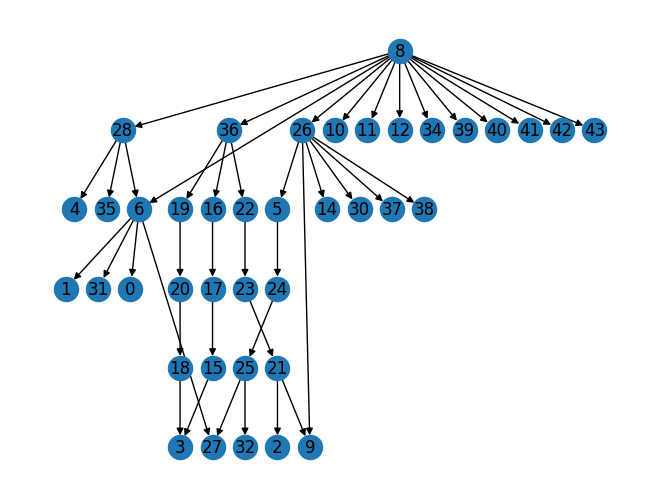

In [187]:
nx.draw(graph, pos=pos, with_labels=True, arrows=True)

In [188]:
ALL_ROOT_CAUSES

['lambdastatusupdater_AWS::Lambda::Function',
 'PetSearch_AWS::ECS::Fargate',
 'petlistadoptions_AWS::ECS::Fargate',
 'petInfo_AWS::DynamoDB::Table',
 'payforadoption_AWS::ECS::Container']

In [189]:
nx.relabel_nodes(graph, mapping, copy=False)
gv.d3(graph, zoom_factor=0.35, layout_algorithm_active=False)

In [190]:
# nx.relabel_nodes(graph, mapping, copy=False)
fig = gv.d3(graph, edge_curvature=0.3, show_node_label=True, zoom_factor=0.75, layout_algorithm_active=True,
            use_node_size_normalization=True, node_size_normalization_max=30, node_size_normalization_min=10) #, 
            # use_edge_size_normalization=True, edge_size_data_source='weight')
fig

In [191]:
graph.nodes(data=True)

NodeDataView({0: {'component': '169.254.170.2_remote', 'x': 171.0, 'y': -162.0, 'color': 'gray', 'shape': 'hexagon', 'size': 20, 'border_color': 'black', 'label_size': 10, 'border_size': 1}, 1: {'component': 'AWSSimpleSystemsManagement_AWS::AWSSimpleSystemsManagement', 'x': 27.0, 'y': -162.0, 'color': 'gray', 'shape': 'hexagon', 'size': 20, 'border_color': 'black', 'label_size': 10, 'border_size': 1}, 2: {'component': 'DynamoDB_AWS::DynamoDB', 'x': 497.0, 'y': -18.0, 'color': 'gray', 'shape': 'hexagon', 'size': 20, 'border_color': 'black', 'label_size': 10, 'border_size': 1}, 3: {'component': 'Evidently_AWS::Evidently', 'x': 281.0, 'y': -18.0, 'color': 'gray', 'shape': 'hexagon', 'size': 20, 'border_color': 'black', 'label_size': 10, 'border_size': 1}, 4: {'component': 'PGSQL Query_remote', 'x': 46.0, 'y': -234.0, 'color': 'gray', 'shape': 'hexagon', 'size': 20, 'border_color': 'black', 'label_size': 10, 'border_size': 1}, 5: {'component': 'PetAdoptionStatusUpdater/prod_AWS::ApiGateway

In [192]:
import IPython

# fig.export_jpg('graph.jpg')
# png_text = fig.to_png()
# IPython.display.PNG(png_text)

---

**Bar plots**

In [193]:
PRIM_RESULTS

{'availability#PetSearch_AWS::ECS::Fargate': {'min': 98.84318766066838,
  'max': 100.0},
 'availability#payforadoption_AWS::ECS::Container': {'min': 100.0,
  'max': 100.0},
 'latency#PetSearch_AWS::ECS::Fargate': {'min': 0.0060127535142492,
  'max': 0.0720621039896987},
 'latency#Servi-searc.us-west-2.elb.amazonaws.com_remote': {'min': 0.0086014515307135,
  'max': 0.03454661369},
 'latency#payforadoption_AWS::ECS::Container': {'min': 0.17703996643115075,
  'max': 0.8253752635703936},
 'latency#petInfo_AWS::DynamoDB::Table': {'min': 0.01591770284769315,
  'max': 0.0221902097885309},
 'latency#petlistadoptions_AWS::ECS::Fargate': {'min': 0.02102461540825895,
  'max': 0.0290069514539759},
 'latency#servi-lista.us-west-2.elb.amazonaws.com_remote': {'min': 0.0326713395363855,
  'max': 0.0440637656562857},
 'latency#servi-searc.us-west-2.elb.amazonaws.com_remote': {'min': 0.01195127919053345,
  'max': 0.2448973717331549}}

In [194]:
from collections import OrderedDict
import matplotlib.pyplot as plt

def process_ranges_and_show_bars(ranges, size=(16,4), w=1, title=None, color='#9e7711', fontsize=20, zero_values=False):
    ordered_results = OrderedDict()
    for k,d in sorted(ranges.items()):
        if k.startswith('latency') or k.startswith('p_'):
            ordered_results[k] = {x:y*w for x,y in d.items()}
        else:
            ordered_results[k] = d
    df = pd.DataFrame.from_dict(ordered_results, orient='index').rename_axis('param')
    diff = (df['max'] - df['min']).astype(int).tolist()
    if not zero_values:
        diff = [x if x > 0 else 1 for x in diff]
    fig, ax = plt.subplots(figsize=size)
    # plot data
    ax.barh(
        y = df.index,
        width = diff, # (df['max'] - df['min']).astype(int),
        left = df['min'],
        color = color
    )
    if title is not None:
        plt.title(title, fontsize=fontsize)
    plt.show()
    return df
                  

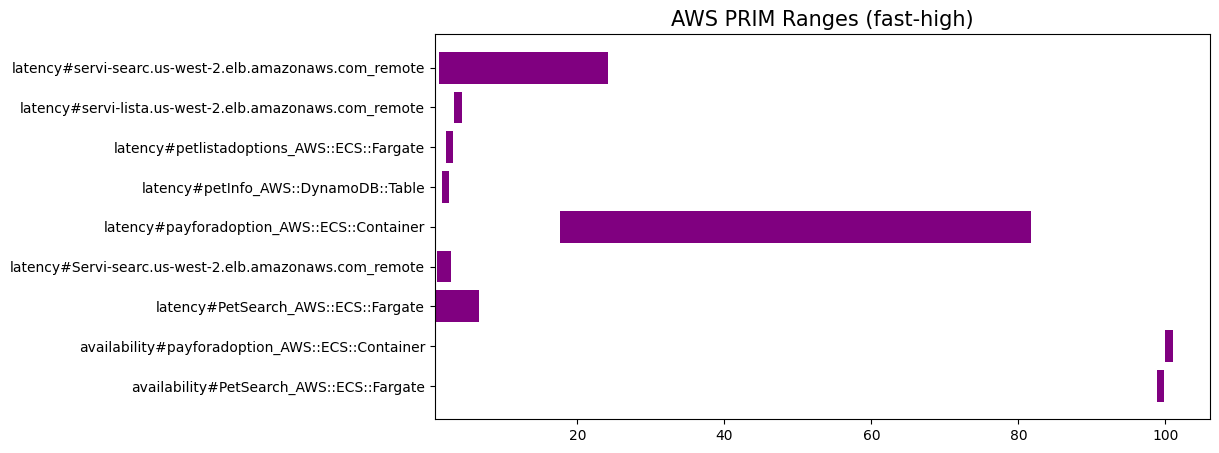

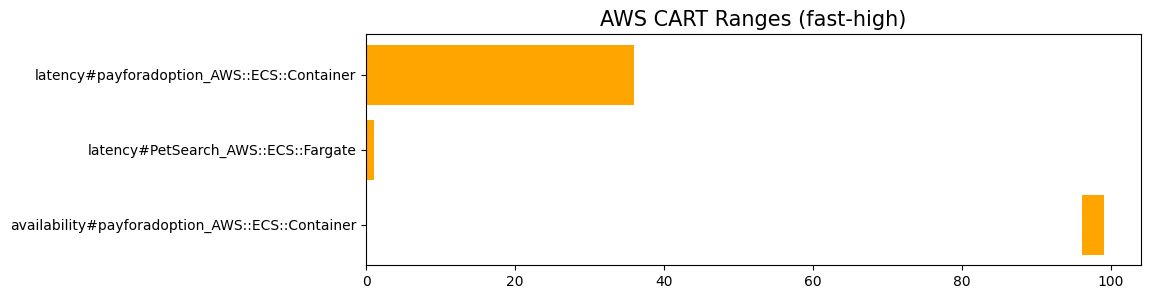

In [195]:
df_prim = process_ranges_and_show_bars(PRIM_RESULTS, title="AWS PRIM Ranges (fast-high)", w=100, size=(10,5), color='purple', fontsize=15)
df_cart = process_ranges_and_show_bars(CART_RESULTS, title="AWS CART Ranges (fast-high)", w=100, size=(10,3), color='orange', fontsize=15)

In [196]:
df_prim

,min,max
param,,
availability#PetSearch_AWS::ECS::Fargate,98.843188,100.000000
availability#payforadoption_AWS::ECS::Container,100.000000,100.000000
latency#PetSearch_AWS::ECS::Fargate,0.601275,7.206210
latency#Servi-searc.us-west-2.elb.amazonaws.com_remote,0.860145,3.454661
latency#payforadoption_AWS::ECS::Container,17.703997,82.537526
latency#petInfo_AWS::DynamoDB::Table,1.591770,2.219021
latency#petlistadoptions_AWS::ECS::Fargate,2.102462,2.900695
latency#servi-lista.us-west-2.elb.amazonaws.com_remote,3.267134,4.406377
latency#servi-searc.us-west-2.elb.amazonaws.com_remote,1.195128,24.489737


In [197]:
df_cart

,min,max
param,,
availability#payforadoption_AWS::ECS::Container,96.078,100.0
latency#PetSearch_AWS::ECS::Fargate,0.000,0.9
latency#payforadoption_AWS::ECS::Container,0.000,36.9


In [198]:
GO_PRIM_RESULTS_FAST_HIGH = {'N_A': {'min': 8.0, 'max': 12.0}, 'S_gw': {'min': 2.5000000000000004, 'max': 7.5}}
GO_PRIM_RESULTS_AVERAGE_AVERAGE = {'N_A': {'min': 0.0, 'max': 23.0}, 'S_gw': {'min': 2.5000000000000004, 'max': 7.5}}
GO_PRIM_RESULTS_FAST_LOW = {'N_A': {'min': 7.0, 'max': 16.0}, 'S_gw': {'min': 1e-15, 'max': 2.5000000000000004}}
GO_PRIM_RESULTS_FAST_AVERAGE = {'N_A': {'min': 1.0, 'max': 19.0}, 'S_gw': {'min': 2.5000000000000004, 'max': 7.5}}

# inf == 25
GO_CART_RESULTS_FAST_HIGH = {'N_B': {'min': 0, 'max': 18.0}, 'N_A': {'min': 0, 'max': 12.5}, 'S_gw': {'min': 2.500000001, 'max': 7.5}}
GO_CART_RESULTS_AVERAGE_AVERAGE = {'N_A': {'min': 20.000000001, 'max': 25}, 'S_gw': {'min': 2.500000001, 'max': 7.5}}
GO_CART_RESULTS_FAST_LOW = {'N_A': {'min': 5.500000001, 'max': 25}, 'N_B': {'min': 8.500000001, 'max': 25}, 'S_gw': {'min': 0, 'max': 2.5}}
GO_CART_RESULTS_FAST_AVERAGE =  {'N_A': {'min': 12.500000001, 'max': 20.0}, 'S_gw': {'min': 2.500000001, 'max': 7.5}}

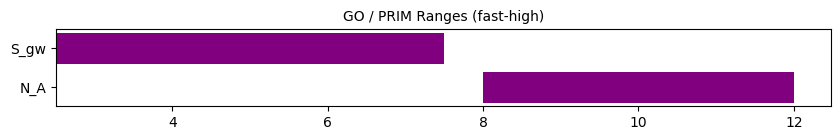

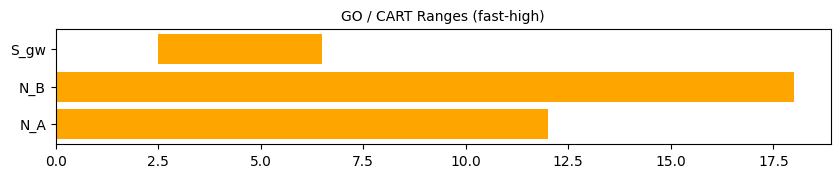

In [199]:
df_prim = process_ranges_and_show_bars(GO_PRIM_RESULTS_FAST_HIGH, title="GO / PRIM Ranges (fast-high)", 
                                       size=(10,1), color='purple', fontsize=10, zero_values=True)
df_cart = process_ranges_and_show_bars(GO_CART_RESULTS_FAST_HIGH, title="GO / CART Ranges (fast-high)", 
                                       size=(10,1.5), color='orange', fontsize=10, zero_values=True)

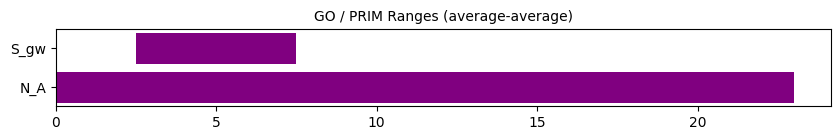

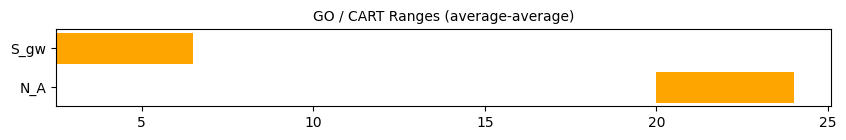

In [200]:
df_prim = process_ranges_and_show_bars(GO_PRIM_RESULTS_AVERAGE_AVERAGE, title="GO / PRIM Ranges (average-average)", 
                                       size=(10,1), color='purple', fontsize=10, zero_values=True)
df_cart = process_ranges_and_show_bars(GO_CART_RESULTS_AVERAGE_AVERAGE, title="GO / CART Ranges (average-average)", 
                                       size=(10,1), color='orange', fontsize=10, zero_values=True)

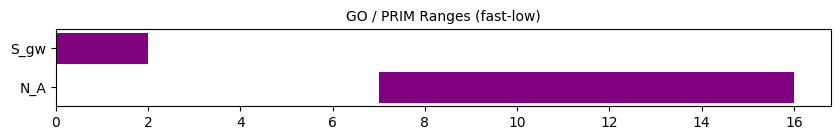

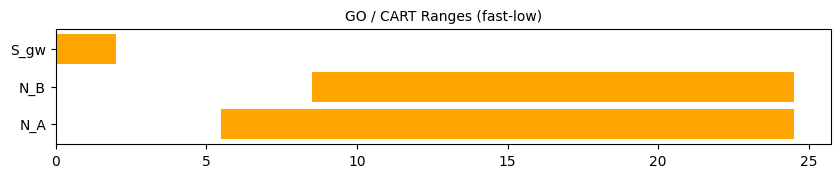

In [201]:
df_prim = process_ranges_and_show_bars(GO_PRIM_RESULTS_FAST_LOW, title="GO / PRIM Ranges (fast-low)", 
                                       size=(10,1), color='purple', fontsize=10, zero_values=True)
df_cart = process_ranges_and_show_bars(GO_CART_RESULTS_FAST_LOW, title="GO / CART Ranges (fast-low)", 
                                       size=(10,1.5), color='orange', fontsize=10, zero_values=True)

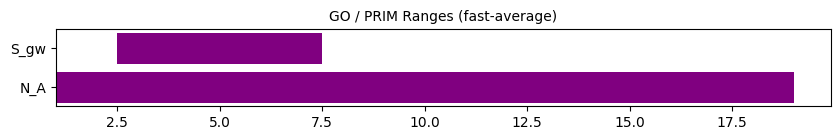

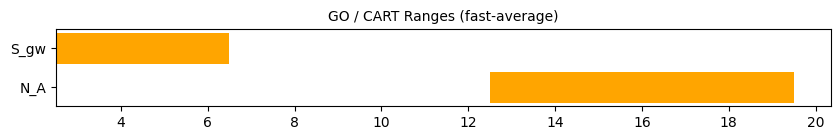

In [202]:
df_prim = process_ranges_and_show_bars(GO_PRIM_RESULTS_FAST_AVERAGE, title="GO / PRIM Ranges (fast-average)", 
                                       size=(10,1), color='purple', fontsize=10, zero_values=True)
df_cart = process_ranges_and_show_bars(GO_CART_RESULTS_FAST_AVERAGE, title="GO / CART Ranges (fast-average)", 
                                       size=(10,1), color='orange', fontsize=10, zero_values=True)

In [203]:
CQRS_PRIM_RESULTS_FAST_AVERAGE = {'r_Z_write': {'min': 0.001, 'max': 0.0021980676328502}}

CQRS_CART_RESULTS_FAST_AVERAGE = {'r_Z_write': {'min': 0.001000001, 'max': 0.002}}

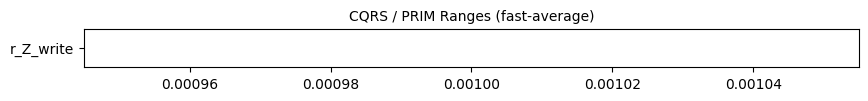

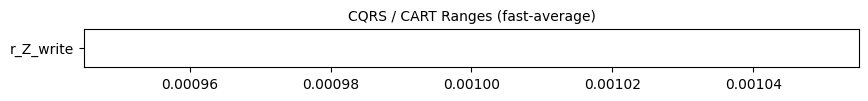

In [204]:
df_prim = process_ranges_and_show_bars(CQRS_PRIM_RESULTS_FAST_AVERAGE, title="CQRS / PRIM Ranges (fast-average)", 
                                       size=(10,0.5), color='purple', fontsize=10, zero_values=True)
df_cart = process_ranges_and_show_bars(CQRS_CART_RESULTS_FAST_AVERAGE, title="CQRS / CART Ranges (fast-average)", 
                                       size=(10,0.5), color='orange', fontsize=10, zero_values=True)

In [205]:
df_prim

,min,max
param,,
r_Z_write,0.001,0.002198


In [206]:
df_cart

,min,max
param,,
r_Z_write,0.001,0.002


In [207]:
ACL_PRIM_RESULTS_FAST_AVERAGE = {'N_A': {'min': 2.0, 'max': 22.0}, 'N_B': {'min': 4.0, 'max': 25.0}, 'p_SS1toACL_A': {'min': 0.6499999999999999, 'max': 0.9}}
ACL_PRIM_RESULTS_FAST_HIGH = {'N_A': {'min': 0.0, 'max': 15.0}, 'N_B': {'min': 7.0, 'max': 23.0}, 'p_SS1toACL_A': {'min': 0.1, 'max': 0.45}}

# inf == 0.9 & 25
ACL_CART_RESULTS_FAST_AVERAGE = {'p_SS1toRef_B': {'min': 0.550000001, 'max': 0.9}, 'N_A': {'min': 5.500000001, 'max': 21.5}}
ACL_CART_RESULTS_FAST_HIGH = {'p_SS1toRef_B': {'min': 0, 'max': 0.55}, 'N_A': {'min': 0, 'max': 12.5}, 'N_B': {'min': 7.500000001, 'max': 25}}


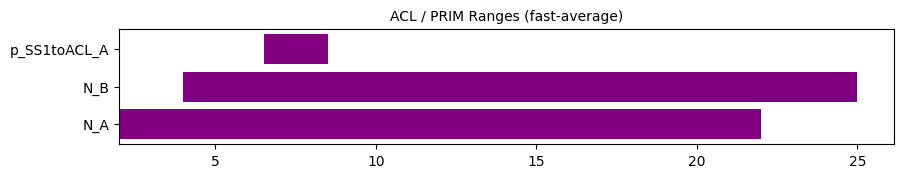

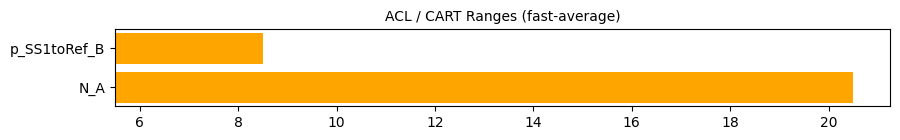

In [208]:
df_prim = process_ranges_and_show_bars(ACL_PRIM_RESULTS_FAST_AVERAGE, title="ACL / PRIM Ranges (fast-average)", 
                                       size=(10,1.5), color='purple', fontsize=10, zero_values=True, w=10)
df_cart = process_ranges_and_show_bars(ACL_CART_RESULTS_FAST_AVERAGE, title="ACL / CART Ranges (fast-average)", 
                                       size=(10,1), color='orange', fontsize=10, zero_values=True, w=10)

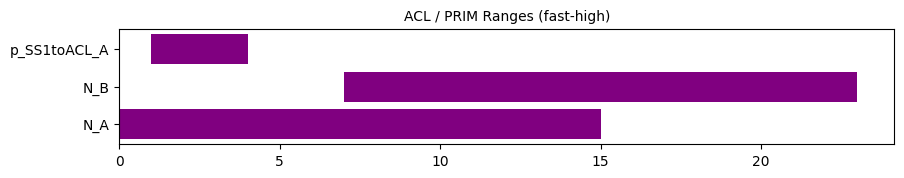

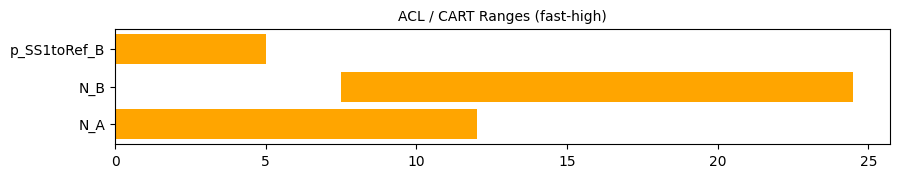

In [209]:
df_prim = process_ranges_and_show_bars(ACL_PRIM_RESULTS_FAST_HIGH, title="ACL / PRIM Ranges (fast-high)", 
                                       size=(10,1.5), color='purple', fontsize=10, zero_values=True, w=10)
df_cart = process_ranges_and_show_bars(ACL_CART_RESULTS_FAST_HIGH, title="ACL / CART Ranges (fast-high)", 
                                       size=(10,1.5), color='orange', fontsize=10, zero_values=True, w=10)